In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s6e2/sample_submission.csv
/kaggle/input/playground-series-s6e2/train.csv
/kaggle/input/playground-series-s6e2/test.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

from xgboost import XGBClassifier
from xgboost import plot_importance

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, \
                           confusion_matrix, ConfusionMatrixDisplay

from sklearn.preprocessing import StandardScaler
import lightgbm as lgb

In [3]:
df = pd.read_csv('/kaggle/input/playground-series-s6e2/train.csv')
df.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [4]:
# 1. Rate Pressure Product
df['RPP'] = df['BP'] * df['Max HR']

# 2. Heart Stress Index (Vectorized version)
# We use np.select or simple addition for speed
df['Heart_Stress_Index'] = (
    (df['Exercise angina'] * 2) + 
    (df['Number of vessels fluro']) +
    np.where(df['Chest pain type'] >= 3, 2, 
             np.where(df['Chest pain type'] == 2, 1, 0))
)

In [5]:
# 3. Bonus: ST Slope interaction (Commonly used with GBDT models)
# This flags the high-risk "Downsloping" or "Flat" ST segments
df['High_Risk_ST'] = ((df['ST depression'] > 1.5) & (df['Slope of ST'] >= 2)).astype(int)

In [6]:
# 1. Rate Pressure Product (RPP)
# Standard clinical calculation: Systolic BP * Heart Rate
df['RPP'] = df['BP'] * df['Max HR']

# 2. Heart Stress Index (Vectorized)
# This uses np.select for high-speed conditional logic
conditions = [
    (df['Chest pain type'] >= 3),
    (df['Chest pain type'] == 2)
]
choices = [2, 1] # 2 points for high pain, 1 for moderate

In [7]:
df['Heart_Stress_Index'] = (
    np.select(conditions, choices, default=0) + # Pain score
    (df['Exercise angina'] * 2) +               # Stress score
    df['Number of vessels fluro']               # Physical blockage score
)

In [8]:
# 3. Bonus: Ischemic Risk Flag (Great for LightGBM)
# Combining ST Depression and Slope into a single interaction feature
df['ST_Risk_Interaction'] = df['ST depression'] * df['Slope of ST']

# Drop the ID column so LightGBM doesn't learn noise
df.drop(columns=['id'], errors='ignore', inplace=True)

print(df[['RPP', 'Heart_Stress_Index', 'ST_Risk_Interaction']].head())

     RPP  Heart_Stress_Index  ST_Risk_Interaction
0  24016                   6                  7.2
1  21375                   0                  0.0
2  24160                   1                  0.0
3  20100                   2                  2.0
4  17500                   7                  7.6


In [9]:
# Define categorical columns (including your new Heart_Stress_Index)
cat_features = [
    'Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 
    'Exercise angina', 'Slope of ST', 'Thallium', 'Heart_Stress_Index'
]

In [10]:
# Ensure they are 'category' dtype for LightGBM
for col in cat_features:
    df[col] = df[col].astype('category')

# Prepare X and y (assuming 'Heart Disease' is your target)
X = df.drop(['Heart Disease', 'id'], axis=1, errors='ignore')
y = df['Heart Disease'].map({'Presence': 1, 'Absence': 0}) # Encode target if string

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
# Create LightGBM datasets
train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=cat_features)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

# Parameters optimized for 600k+ rows
params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,      # Standard starting point
    'feature_fraction': 0.9,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1
}

In [12]:
# Train the model
model = lgb.train(
    params,
    train_data,
    valid_sets=[test_data],
    num_boost_round=1000,
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[454]	valid_0's auc: 0.955047


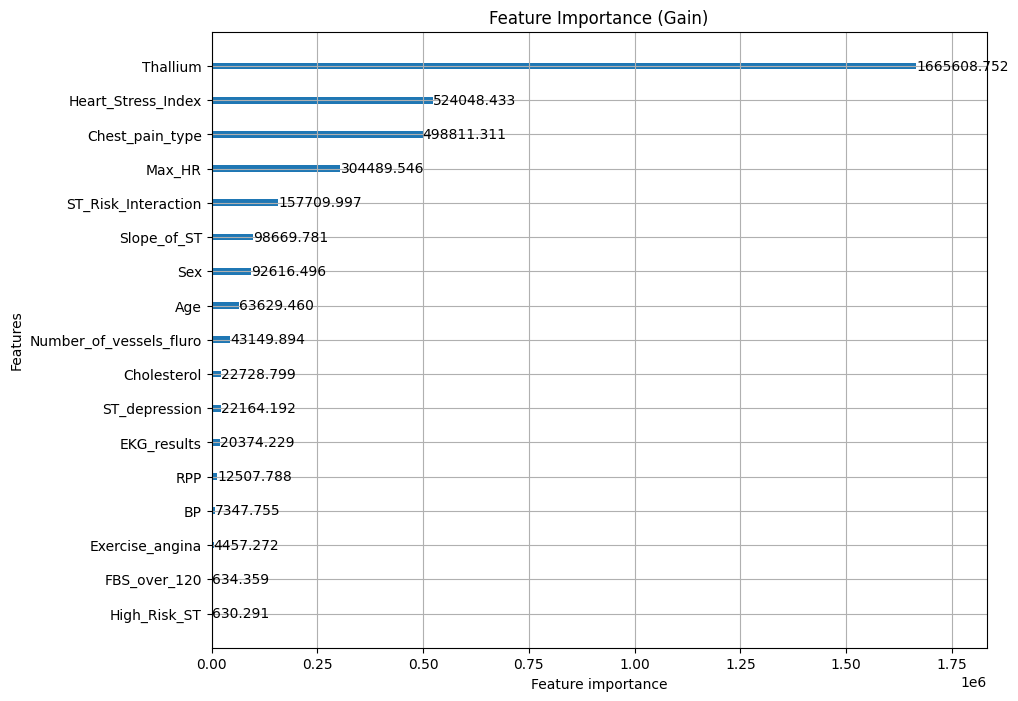

In [13]:
# Plot Feature Importance
lgb.plot_importance(model, importance_type='gain', figsize=(10, 8))
plt.title("Feature Importance (Gain)")
plt.show()

In [14]:
# 1. Generate probabilities using the best iteration from training
y_prob = model.predict(X_test, num_iteration=model.best_iteration)

# 2. Create the results DataFrame
# We'll include the actual labels (y_test) to make the CSV useful for review
output_df = pd.DataFrame({
    'Actual_Label': y_test.values,
    'Predicted_Probability': y_prob,
    'Predicted_Class': [1 if x >= 0.5 else 0 for x in y_prob]
})

# 3. Map the binary classes back to original labels if needed
output_df['Prediction_Text'] = output_df['Predicted_Class'].map({1: 'Presence', 0: 'Absence'})

# 4. Export to CSV
output_df.to_csv('heart_disease_predictions.csv', index=False)

print("Export complete! 'heart_disease_predictions.csv' has been saved.")

Export complete! 'heart_disease_predictions.csv' has been saved.
